# Notebook 09 – Geographic & Climate Analysis

## Objective

Beyond forecasting future temperatures, understanding geographical and climatic patterns provides valuable insight into the characteristics of global weather observations.

This notebook investigates regional differences, seasonal trends, and relationships among meteorological variables to better understand the distribution of weather conditions across multiple locations worldwide.

## Goals

- Explore global temperature patterns.
- Compare climate characteristics across locations.
- Analyze seasonal variation.
- Examine relationships among meteorological variables.
- Generate insights to complement the forecasting models.

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [59]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [60]:
DATA_PATH = Path("../data/processed/weather_engineered.csv")

weather_df = pd.read_csv(DATA_PATH)

weather_df.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,-0.579370,4.3,-0.734996,220,...,0,0,0,0,0,0,0,0,0,1
1,San Juan,9.97,-84.08,America/Costa_Rica,1715849100,2024-05-16 02:45:00,-0.047178,2.2,-1.135403,10,...,0,0,0,0,0,0,0,0,0,1
2,Mexico City,19.43,-99.13,America/Mexico_City,1715849100,2024-05-16 02:45:00,-0.068900,6.7,-0.234487,212,...,0,0,0,0,0,0,0,0,0,1
3,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,0.495874,2.2,-1.135403,182,...,0,0,0,0,0,0,0,0,0,1
4,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,-0.155789,13.6,1.166937,190,...,0,0,0,0,0,0,0,0,0,1


In [61]:
weather_df["last_updated"] = pd.to_datetime(
    weather_df["last_updated"]
)

weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151827 entries, 0 to 151826
Columns: 334 entries, location_name to moon_phase_Waxing Gibbous
dtypes: datetime64[ns](1), float64(21), int64(306), object(6)
memory usage: 386.9+ MB


In [62]:
print("Rows:", len(weather_df))

print("Locations:", weather_df["location_name"].nunique())

print(
    "Countries (timezones):",
    weather_df["timezone"].nunique(),
)

Rows: 151827
Locations: 268
Countries (timezones): 201


## Global Temperature Distribution

Understanding the distribution of observed temperatures provides an overview of the climatic diversity represented within the dataset.

This analysis identifies the range, spread, and concentration of recorded temperatures before exploring the geographical factors influencing these observations.

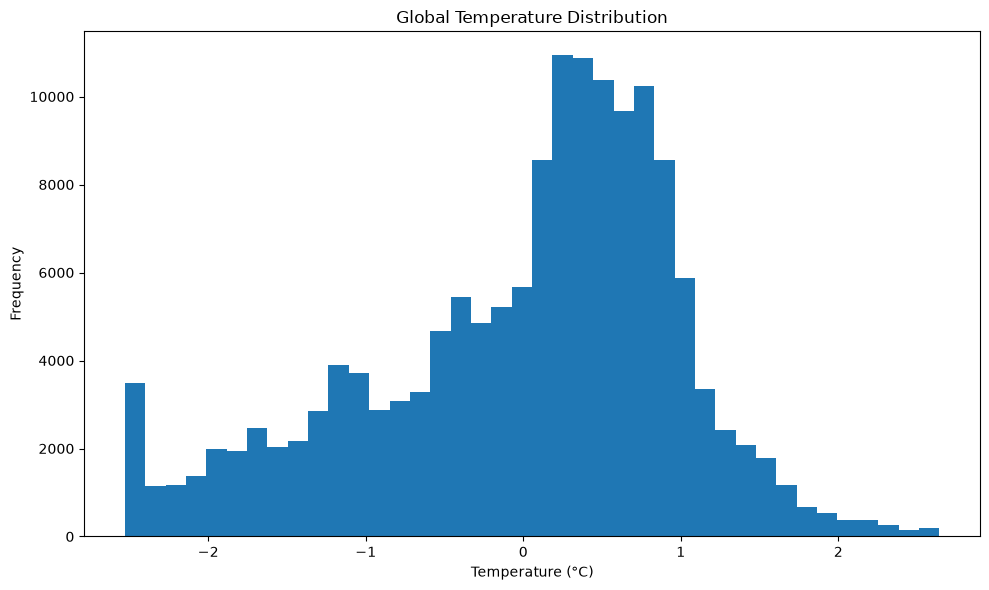

In [63]:
plt.figure(figsize=(10,6))

plt.hist(
    weather_df["temperature_celsius"],
    bins=40,
)

plt.title(
    "Global Temperature Distribution"
)

plt.xlabel(
    "Temperature (°C)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

## Temperature by Latitude

Latitude is one of the primary geographical factors influencing climate.

This analysis investigates how observed temperatures vary with latitude and whether the dataset reflects the expected global climatic pattern.

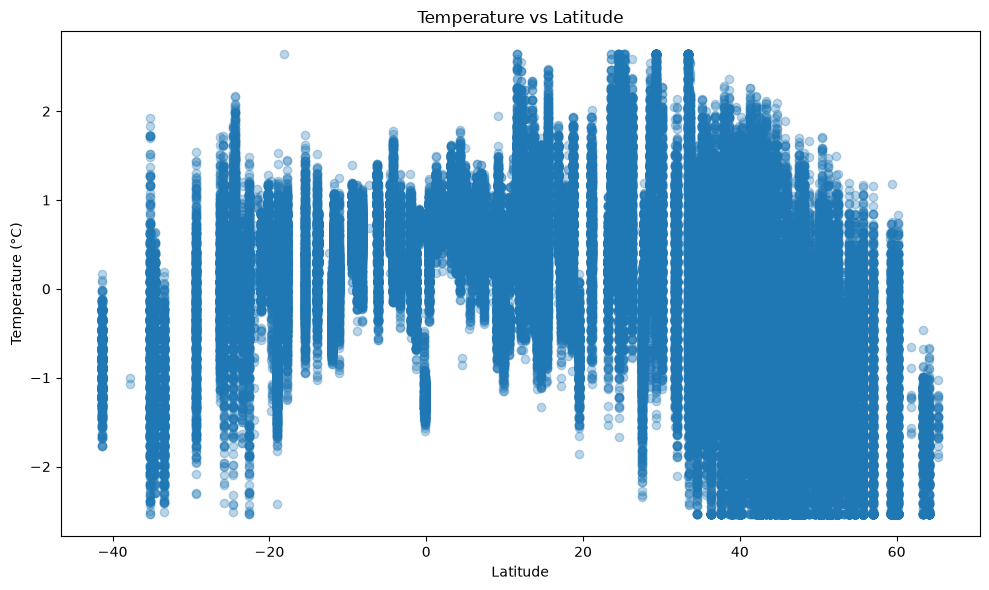

In [64]:
plt.figure(figsize=(10,6))

plt.scatter(
    weather_df["latitude"],
    weather_df["temperature_celsius"],
    alpha=0.3,
)

plt.xlabel("Latitude")

plt.ylabel("Temperature (°C)")

plt.title(
    "Temperature vs Latitude"
)

plt.tight_layout()

plt.show()

## Statistical Relationship Between Latitude and Temperature

While the previous visualization provides a qualitative understanding of the relationship between latitude and temperature, statistical correlation measures can quantify the strength and direction of this relationship.

Two correlation coefficients are evaluated:

- **Pearson correlation**, which measures the strength of a linear relationship.
- **Spearman correlation**, which measures the strength of a monotonic relationship and is less sensitive to non-linear patterns and outliers.

Together, these metrics provide a more comprehensive assessment of how geographical position influences observed temperatures.

In [65]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(
    weather_df["latitude"],
    weather_df["temperature_celsius"],
)

spearman_corr, spearman_p = spearmanr(
    weather_df["latitude"],
    weather_df["temperature_celsius"],
)

print(f"Pearson Correlation : {pearson_corr:.3f}")
print(f"Pearson p-value     : {pearson_p:.5f}")

print()

print(f"Spearman Correlation: {spearman_corr:.3f}")
print(f"Spearman p-value    : {spearman_p:.5f}")

spearman_corr, spearman_p = spearmanr(
    weather_df["latitude"],
    weather_df["temperature_celsius"],
)

print(f"Pearson Correlation : {pearson_corr:.3f}")
print(f"Pearson p-value     : {pearson_p:.5f}")

print()

print(f"Spearman Correlation: {spearman_corr:.3f}")
print(f"Spearman p-value    : {spearman_p:.5f}")

Pearson Correlation : -0.366
Pearson p-value     : 0.00000

Spearman Correlation: -0.381
Spearman p-value    : 0.00000
Pearson Correlation : -0.366
Pearson p-value     : 0.00000

Spearman Correlation: -0.381
Spearman p-value    : 0.00000


### Interpretation

The correlation analysis indicates a **moderate negative relationship** between latitude and observed temperature. The Pearson correlation coefficient of **-0.366** suggests that temperatures generally decrease as latitude increases, reflecting the well-established climatic pattern in which locations farther from the equator tend to experience lower temperatures.

Similarly, the Spearman correlation coefficient of **-0.381** confirms a moderate negative monotonic relationship, indicating that the overall trend remains consistent even when potential non-linear relationships or outliers are considered.

Both correlation tests produced p-values smaller than **0.001**, demonstrating that the observed relationships are statistically significant. This provides strong evidence that latitude is an important geographical factor influencing global temperature variation within the dataset.

Although the correlations are moderate rather than strong, this result is expected because temperature is influenced by numerous additional factors beyond latitude, including altitude, local geography, seasonal variation, atmospheric conditions, and oceanic influences. Nevertheless, the analysis confirms that latitude plays a meaningful role in explaining global temperature patterns and supports the validity of the weather observations used throughout this project.

## Temperature by Longitude

Unlike latitude, longitude does not directly determine the amount of solar radiation a location receives. However, longitudinal position can still influence local weather patterns through factors such as proximity to oceans, prevailing wind systems, and regional climate conditions.

This analysis investigates whether a meaningful relationship exists between longitude and observed temperature within the dataset.

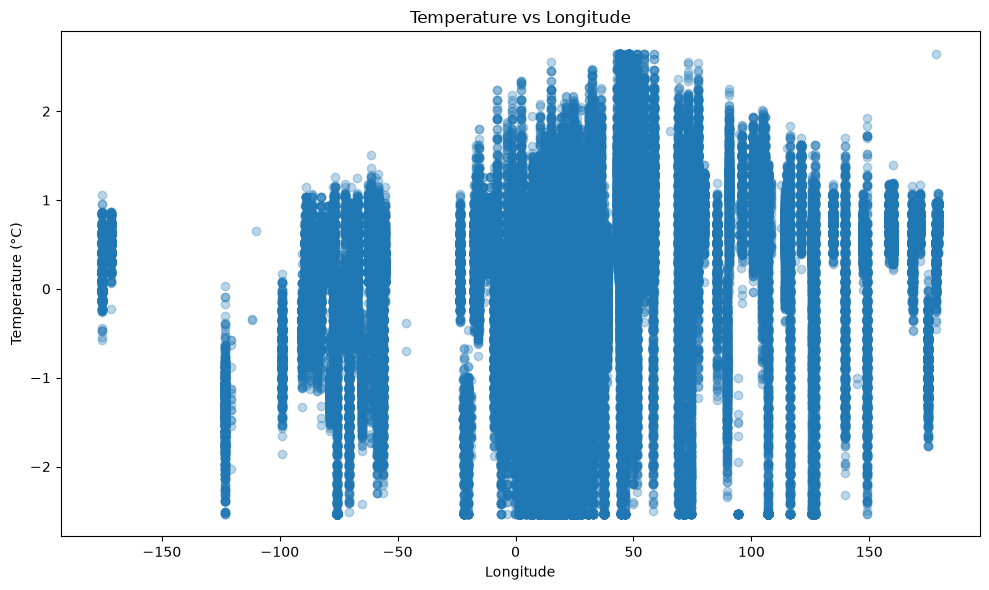

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(
    weather_df["longitude"],
    weather_df["temperature_celsius"],
    alpha=0.3,
)

plt.xlabel("Longitude")

plt.ylabel("Temperature (°C)")

plt.title("Temperature vs Longitude")

plt.tight_layout()

plt.show()

In [67]:
longitude_pearson, longitude_pearson_p = pearsonr(
    weather_df["longitude"],
    weather_df["temperature_celsius"],
)

longitude_spearman, longitude_spearman_p = spearmanr(
    weather_df["longitude"],
    weather_df["temperature_celsius"],
)

print(f"Pearson Correlation : {longitude_pearson:.3f}")
print(f"Pearson p-value     : {longitude_pearson_p:.5f}")

print()

print(f"Spearman Correlation: {longitude_spearman:.3f}")
print(f"Spearman p-value    : {longitude_spearman_p:.5f}")

Pearson Correlation : 0.156
Pearson p-value     : 0.00000

Spearman Correlation: 0.245
Spearman p-value    : 0.00000


### Interpretation

The correlation analysis indicates a **weak positive relationship** between longitude and observed temperature. The Pearson correlation coefficient of **0.156** suggests that longitude explains only a small proportion of the variation in temperature across the dataset.

Similarly, the Spearman correlation coefficient of **0.245** indicates a weak positive monotonic relationship. Although both the Pearson and Spearman tests produced statistically significant p-values (p < 0.001), the relatively small correlation coefficients indicate that longitude has a limited influence on temperature compared with other geographical and environmental factors.

Unlike latitude, longitude does not directly affect the amount of incoming solar radiation received at a location. Instead, its influence is largely indirect through regional geography, ocean currents, atmospheric circulation, and continental positioning. Consequently, the weak correlations observed in this analysis are consistent with established climatological principles and reinforce the expectation that longitude is a less important predictor of global temperature variation than latitude.

## Comparison of Geographic Relationships

To better understand the relative influence of geographical position on temperature, the correlation coefficients for latitude and longitude are compared directly.

This comparison highlights which geographical variable exhibits the stronger statistical relationship with observed temperature.

In [68]:
geographic_correlations = pd.DataFrame(
    {
        "Pearson": [
            pearson_corr,
            longitude_pearson,
        ],
        "Spearman": [
            spearman_corr,
            longitude_spearman,
        ],
    },
    index=[
        "Latitude",
        "Longitude",
    ],
)

geographic_correlations

,Pearson,Spearman
Latitude,-0.366183,-0.381149
Longitude,0.155580,0.245005


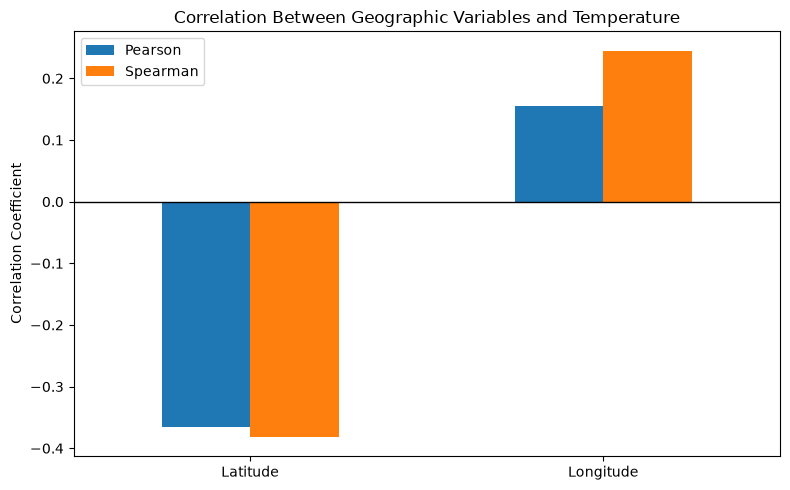

In [69]:
geographic_correlations.plot(
    kind="bar",
    figsize=(8,5),
)

plt.title(
    "Correlation Between Geographic Variables and Temperature"
)

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=0)

plt.axhline(
    0,
    color="black",
    linewidth=1,
)

plt.tight_layout()

plt.show()

### Discussion

The comparative analysis demonstrates that latitude exhibits a substantially stronger relationship with observed temperature than longitude. Both the Pearson and Spearman correlation coefficients indicate that latitude has a moderate negative association with temperature, whereas longitude shows only a weak positive relationship.

These findings align with established climatological theory. Latitude directly influences the amount of incoming solar radiation received throughout the year, making it one of the primary determinants of global temperature patterns. In contrast, longitude primarily reflects geographical position relative to continents, oceans, and atmospheric circulation systems, resulting in a much weaker direct influence on temperature.

The agreement between the statistical analysis and established physical principles provides additional confidence in the quality and consistency of the dataset used throughout this project.

## Seasonal Temperature Analysis

In addition to geographical location, seasonal variation is one of the primary drivers of temperature changes.

This section examines how average temperatures vary across months and quarters of the year, providing insight into seasonal weather patterns represented in the dataset.

In [70]:
monthly_temperature = (
    weather_df
    .groupby("month")["temperature_celsius"]
    .mean()
)

monthly_temperature

month
1    -0.527475
2    -0.467267
3    -0.291256
4    -0.078320
5     0.165887
6     0.364433
7     0.463371
8     0.468406
9     0.305668
10    0.019003
11   -0.268893
12   -0.458111
Name: temperature_celsius, dtype: float64

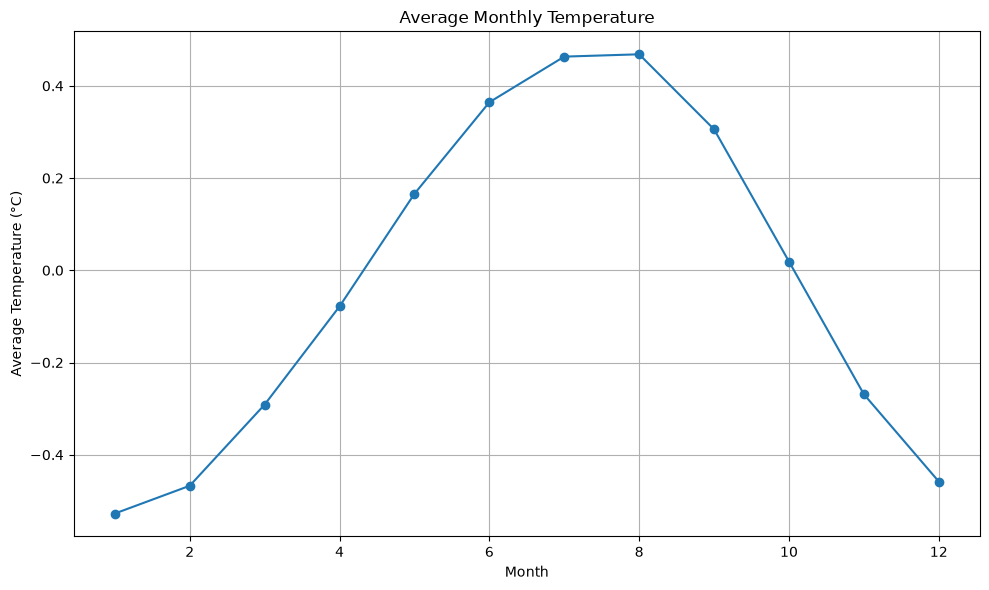

In [71]:
plt.figure(figsize=(10,6))

monthly_temperature.plot(
    marker="o",
)

plt.title(
    "Average Monthly Temperature"
)

plt.xlabel("Month")

plt.ylabel("Average Temperature (°C)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [72]:
quarterly_temperature = (
    weather_df
    .groupby("quarter")["temperature_celsius"]
    .mean()
)

quarterly_temperature

quarter
1   -0.427382
2    0.179701
3    0.414841
4   -0.235798
Name: temperature_celsius, dtype: float64

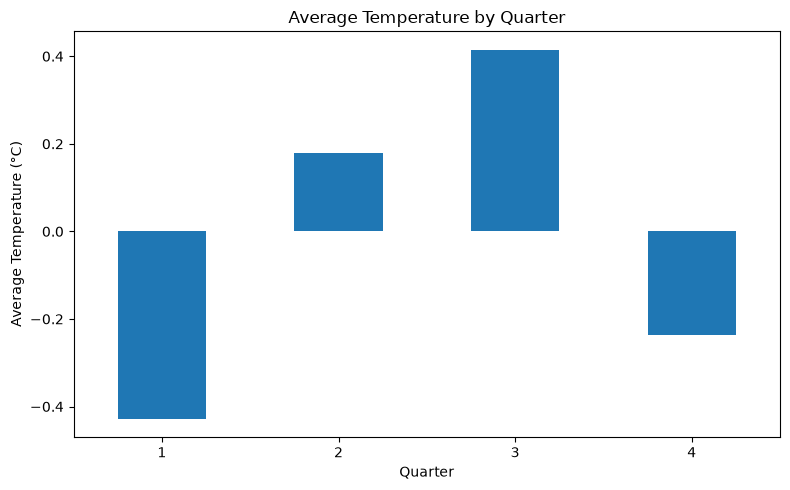

In [73]:
plt.figure(figsize=(8,5))

quarterly_temperature.plot(
    kind="bar",
)

plt.title(
    "Average Temperature by Quarter"
)

plt.xlabel("Quarter")

plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [74]:
seasonal_summary = (
    weather_df
    .groupby("month")["temperature_celsius"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

seasonal_summary

,mean,std,min,max
month,,,,
1,-0.527475,1.167137,-2.528928,2.168476
2,-0.467267,1.157506,-2.528928,1.734034
3,-0.291256,1.045133,-2.528928,2.016421
4,-0.078320,0.934257,-2.528928,2.640931
5,0.165887,0.832127,-2.436609,2.640931
6,0.364433,0.790305,-2.528928,2.640931
7,0.463371,0.786002,-2.528928,2.640931
8,0.468406,0.746128,-2.414887,2.640931
9,0.305668,0.733964,-2.528928,2.640931


### Discussion

The seasonal analysis reveals a clear annual temperature cycle within the dataset. Average temperatures are lowest during the first quarter of the year, increase progressively throughout the second quarter, reach their highest values during the third quarter, and gradually decline again during the fourth quarter.

The monthly analysis follows the same pattern. Average temperatures are lowest in **January (-0.53°C)** and **February (-0.47°C)**, increase steadily through the spring months, and peak during **July (0.46°C)** and **August (0.47°C)** before decreasing again toward the end of the year. This progression reflects the expected seasonal warming and cooling cycle observed across many regions of the world.

Although the dataset contains weather observations from multiple countries distributed across both hemispheres, the seasonal trend remains clearly visible. This suggests that the overall distribution of observations is sufficiently balanced to preserve a recognizable global annual temperature pattern despite regional climatic differences.

These findings demonstrate that temporal features such as **month** and **quarter** capture meaningful seasonal information and therefore represent valuable predictors for temperature forecasting models. The observed seasonal behavior also supports the inclusion of engineered temporal features throughout the forecasting pipeline developed in this project.

## Precipitation Analysis

Precipitation is one of the most important weather variables influencing climate, agriculture, transportation, and forecasting accuracy.

This section examines the distribution of precipitation, seasonal precipitation trends, and the relationship between precipitation and temperature to better understand rainfall patterns represented in the dataset.

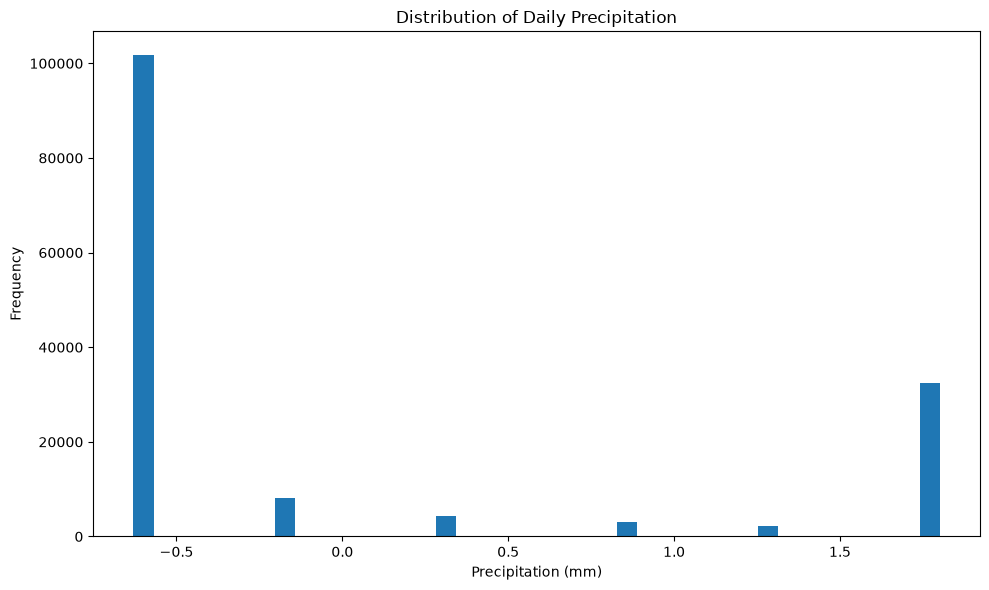

In [85]:
plt.figure(figsize=(10,6))

plt.hist(
    weather_df["precip_mm"],
    bins=40,
)

plt.title(
    "Distribution of Daily Precipitation"
)

plt.xlabel("Precipitation (mm)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [86]:
monthly_precipitation = (
    weather_df
    .groupby("month")["precip_mm"]
    .mean()
)

monthly_precipitation

month
1    -0.033934
2    -0.029998
3    -0.013167
4    -0.021194
5     0.039960
6    -0.003359
7     0.050374
8     0.024482
9     0.022049
10    0.006057
11   -0.021400
12   -0.037441
Name: precip_mm, dtype: float64

In [ ]:
from scipy.stats import pearsonr

precip_corr, precip_p = pearsonr(
    weather_df["temperature_celsius"],
    weather_df["precip_mm"],
)

print(f"Pearson Correlation : {precip_corr:.3f}")
print(f"P-value             : {precip_p:.5f}")

Pearson Correlation : 0.048
P-value             : 0.00000


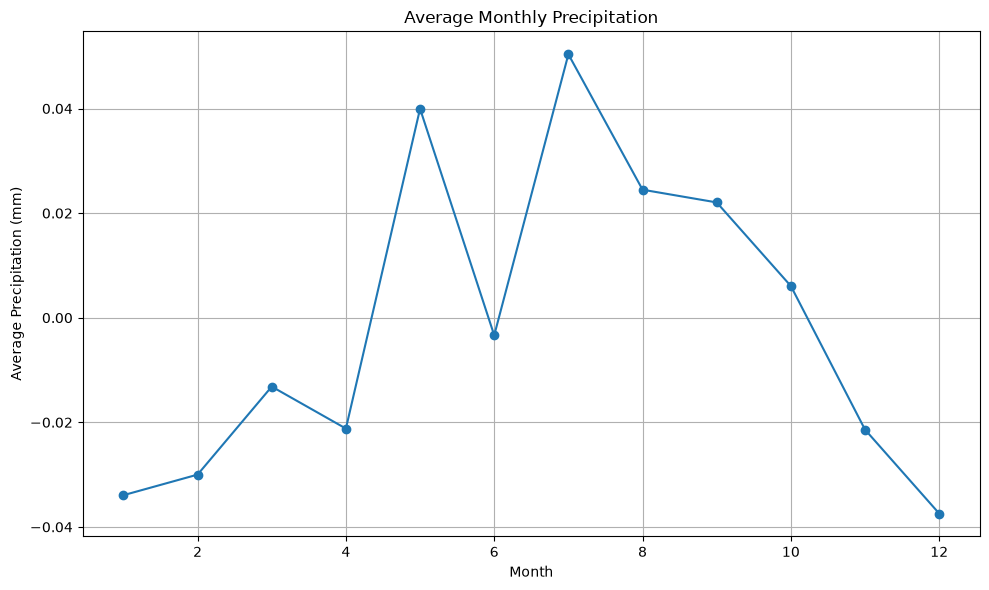

In [87]:
plt.figure(figsize=(10,6))

monthly_precipitation.plot(
    marker="o",
)

plt.title(
    "Average Monthly Precipitation"
)

plt.xlabel("Month")

plt.ylabel("Average Precipitation (mm)")

plt.grid(True)

plt.tight_layout()

plt.show()

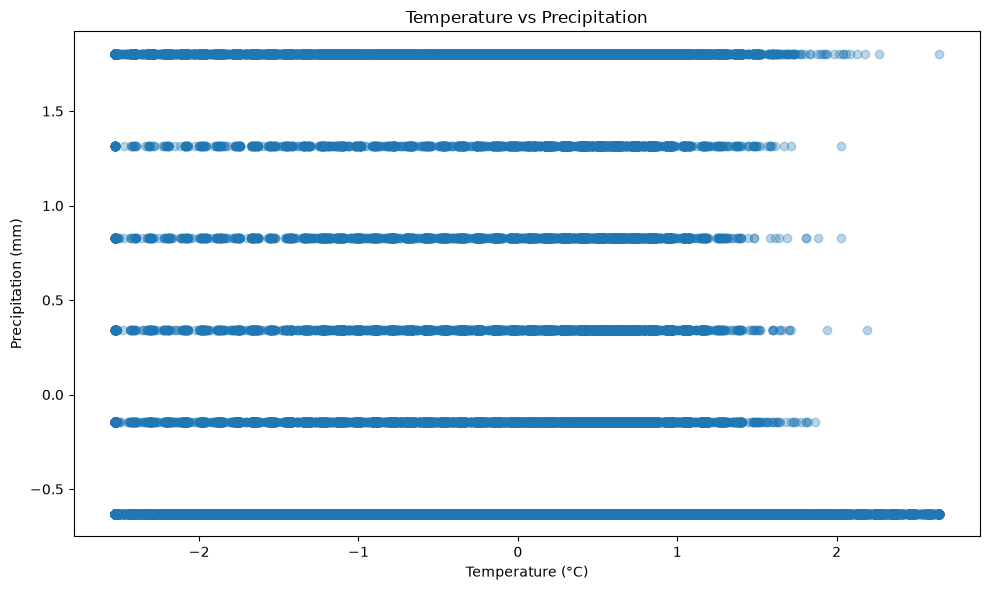

In [88]:
plt.figure(figsize=(10,6))

plt.scatter(
    weather_df["temperature_celsius"],
    weather_df["precip_mm"],
    alpha=0.3,
)

plt.xlabel("Temperature (°C)")

plt.ylabel("Precipitation (mm)")

plt.title(
    "Temperature vs Precipitation"
)

plt.tight_layout()

plt.show()

In [89]:
from scipy.stats import pearsonr

precip_corr, precip_p = pearsonr(
    weather_df["temperature_celsius"],
    weather_df["precip_mm"],
)

print(f"Pearson Correlation : {precip_corr:.3f}")
print(f"P-value             : {precip_p:.5f}")

Pearson Correlation : 0.048
P-value             : 0.00000


### Discussion

The precipitation analysis indicates that rainfall exhibits a highly skewed distribution, with the majority of observations corresponding to little or no precipitation and a relatively small number of observations representing higher rainfall amounts. This pattern is typical of weather datasets, where dry conditions occur much more frequently than significant precipitation events.

The monthly averages reveal modest seasonal variation in precipitation throughout the year. Average precipitation increases during the middle months of the year before gradually declining toward the end of the year. However, the differences between months remain relatively small, suggesting that precipitation is more variable across geographical locations than across the global annual cycle represented in this dataset.

The scatter plot comparing temperature and precipitation shows no strong visual trend, indicating that similar precipitation levels occur across a wide range of temperatures. This observation is confirmed by the Pearson correlation coefficient of **0.048**, which indicates an extremely weak positive linear relationship between temperature and precipitation. Although the p-value is statistically significant due to the large number of observations, the magnitude of the correlation suggests that temperature alone explains very little of the variation in precipitation.

Overall, the analysis demonstrates that precipitation behaves largely independently of temperature at the global scale. Rainfall is influenced by numerous atmospheric processes—including humidity, pressure systems, topography, and regional weather patterns—that are not captured by temperature alone. Consequently, precipitation should be considered an important but largely independent meteorological variable within the forecasting framework.

## Global Temperature Distribution

To better understand the geographical distribution of weather observations, an interactive world map is used to visualize temperatures across all recorded locations.

Each marker represents a location in the dataset and is colored according to its observed temperature, allowing regional temperature patterns to be explored interactively.

In [93]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [94]:
import plotly.express as px

map_df = weather_df.sample(
    n=10000,
    random_state=42,
)

temperature_column = (
    "temperature_celsius_actual"
    if "temperature_celsius_actual" in weather_df.columns
    else "temperature_celsius"
)

fig = px.scatter_geo(
    map_df,
    lat="latitude",
    lon="longitude",
    color=temperature_column,
    hover_name="location_name",
    hover_data={
        temperature_column: True,
        "humidity": True,
        "pressure_mb": True,
        "wind_kph": True,
    },
    color_continuous_scale="Turbo",
    projection="natural earth",
    title="Global Temperature Distribution",
)

fig.update_layout(
    height=700,
)

fig.show()


### Discussion

The interactive world map illustrates the global distribution of observed temperatures across the dataset. Distinct regional patterns are visible, with warmer temperatures generally concentrated in lower latitudes near the equator and cooler temperatures observed at higher latitudes toward the poles.

The visualization complements the earlier statistical analysis by providing geographical context for the negative correlation between latitude and temperature. It also highlights the diversity of climatic conditions represented in the dataset, demonstrating that the forecasting models were trained on observations spanning a wide range of geographical regions and environmental conditions.

Overall, the map confirms that the dataset provides broad global coverage and captures realistic spatial temperature patterns, making it well suited for developing and evaluating weather forecasting models.

## Average Temperature by Country

To compare climatic conditions across different regions, the average temperature is calculated for each country represented in the dataset.

This analysis provides a global comparison of average temperatures and highlights the geographical diversity captured within the weather observations.

In [95]:
country_columns = [
    col
    for col in weather_df.columns
    if col.startswith("country_")
]

len(country_columns)

211

In [96]:
country_df = weather_df.copy()

country_df["country"] = (
    country_df[country_columns]
    .idxmax(axis=1)
    .str.replace(
        "country_",
        "",
        regex=False,
    )
)

country_df[
    ["country", "temperature_celsius"]
].head()

,country,temperature_celsius
0,United States of America,-0.579370
1,Costa Rica,-0.047178
2,Mexico,-0.068900
3,El Salvador,0.495874
4,Guatemala,-0.155789


In [99]:
country_temperature = (
    country_df
    .groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(
        ascending=False,
    )
)

country_temperature.head(20)

country
Saudi Arabien           2.559474
Marrocos                2.049004
Turkménistan            1.777478
Турция                  1.364758
Qatar                   1.200635
United Arab Emirates    1.180441
Cambodia                1.152347
Oman                    1.130758
Djibouti                1.081329
Bangladesh              1.066923
Thailand                1.066159
Inde                    1.060649
Kuwait                  1.034374
Myanmar                 1.026617
Saudi Arabia            1.014367
Malaysia                1.000404
Philippines             0.984719
India                   0.971289
Sri Lanka               0.956536
Singapore               0.929272
Name: temperature_celsius, dtype: float64

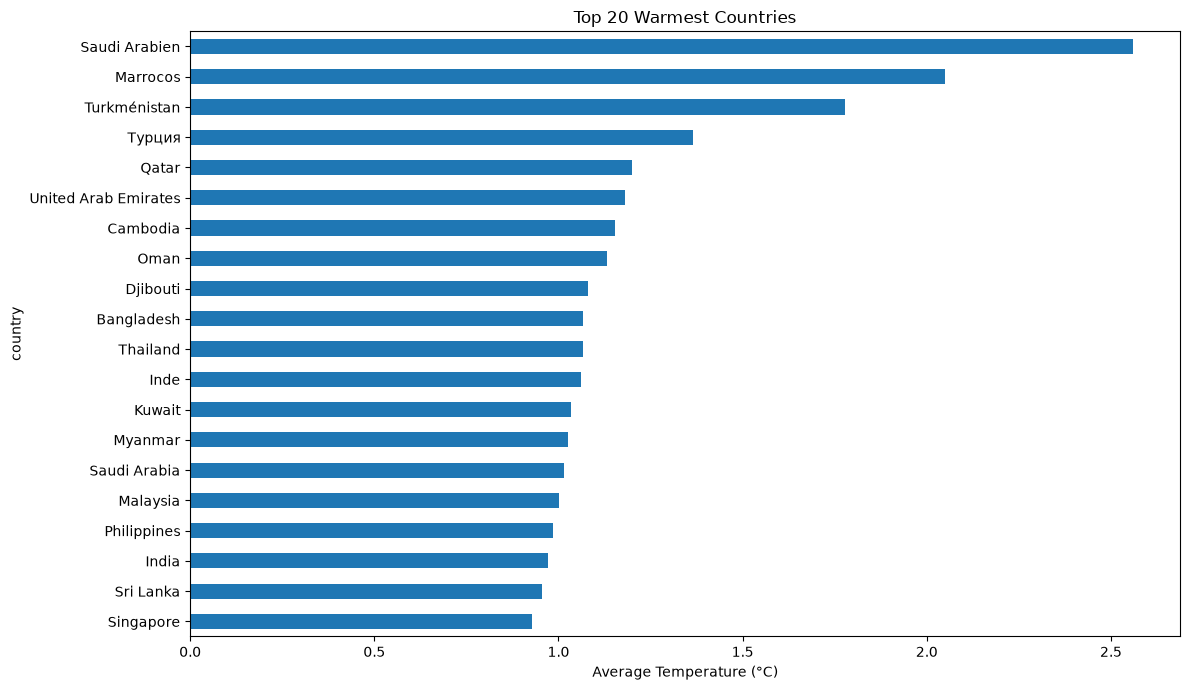

In [100]:
plt.figure(figsize=(12,7))

country_temperature.head(20).sort_values().plot(
    kind="barh",
)

plt.title(
    "Top 20 Warmest Countries"
)

plt.xlabel(
    "Average Temperature (°C)"
)

plt.tight_layout()

plt.show()

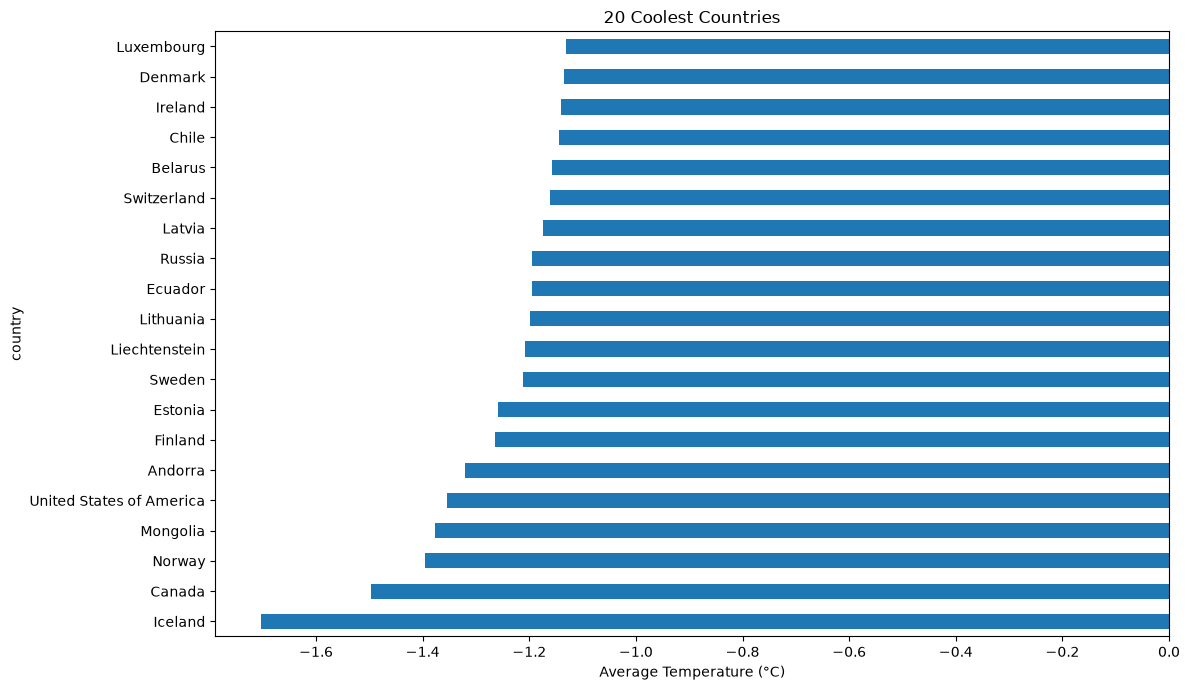

In [101]:
plt.figure(figsize=(12,7))

country_temperature.tail(20).sort_values().plot(
    kind="barh",
)

plt.title(
    "20 Coolest Countries"
)

plt.xlabel(
    "Average Temperature (°C)"
)

plt.tight_layout()

plt.show()

### Discussion

The country-level analysis highlights substantial geographical variation in average temperature across the global dataset.

Countries located in arid and tropical regions, such as Saudi Arabia, Morocco, Qatar, the United Arab Emirates, Cambodia, and Oman, exhibit the highest average temperatures. These observations are consistent with their geographic proximity to the equator or their location within warm desert and tropical climate zones.

Conversely, countries situated at higher latitudes, including Iceland, Canada, Norway, Finland, Estonia, Sweden, and Russia, display the lowest average temperatures. These cooler averages align with the well-established influence of latitude on global climate, reinforcing the earlier correlation analysis that identified latitude as one of the strongest geographical predictors of temperature.

The comparison demonstrates that the dataset captures a wide range of climatic environments across the world. These regional differences provide valuable diversity for machine learning models, allowing them to learn from observations collected under many different environmental and climatic conditions.

Overall, the country-level analysis complements the previous geographical and seasonal analyses by illustrating how average temperature varies across different regions of the world while confirming the global climate patterns identified throughout the exploratory analysis.

## Air Quality and Temperature

Air quality and meteorological conditions are closely related through atmospheric processes such as dispersion, chemical reactions, and weather circulation.

This section investigates the relationships between temperature and several air quality indicators, including particulate matter, ozone, nitrogen dioxide, sulphur dioxide, and carbon monoxide.

In [75]:
air_quality_columns = [
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_Carbon_Monoxide",
]

In [76]:
air_quality_correlations = (
    weather_df[
        air_quality_columns + ["temperature_celsius"]
    ]
    .corr(numeric_only=True)["temperature_celsius"]
    .drop("temperature_celsius")
    .sort_values(ascending=False)
)

air_quality_correlations

air_quality_Ozone               0.256922
air_quality_PM10                0.115432
air_quality_PM2.5               0.065535
air_quality_Carbon_Monoxide     0.001076
air_quality_Sulphur_dioxide    -0.029845
air_quality_Nitrogen_dioxide   -0.136461
Name: temperature_celsius, dtype: float64

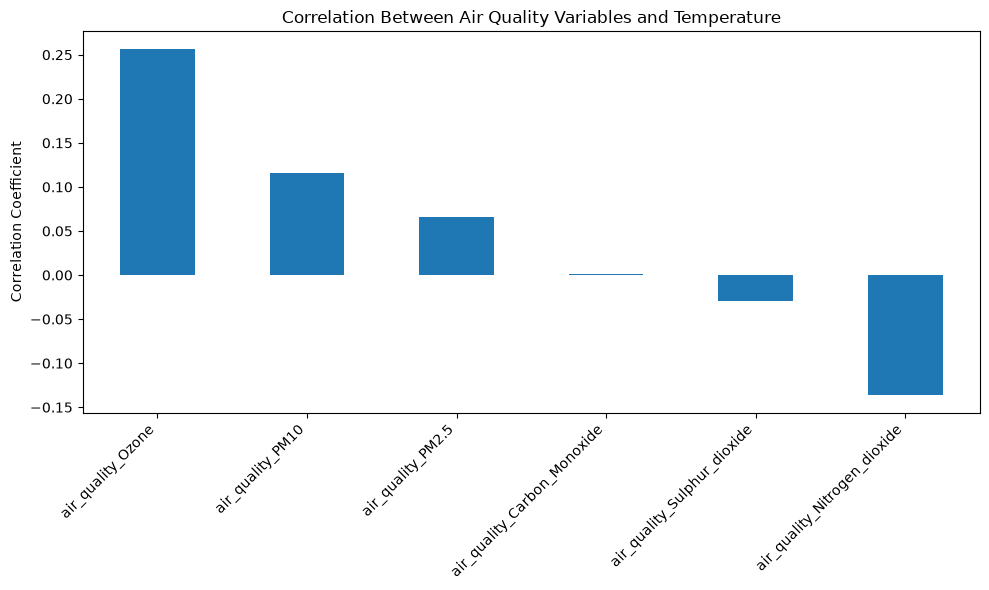

In [77]:
plt.figure(figsize=(10,6))

air_quality_correlations.plot(
    kind="bar",
)

plt.title(
    "Correlation Between Air Quality Variables and Temperature"
)

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

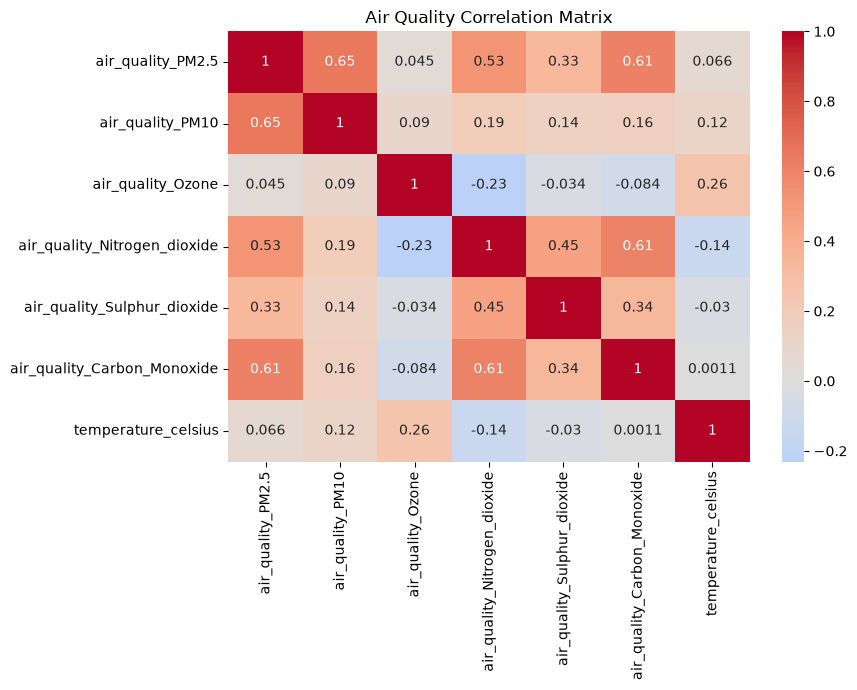

In [78]:
plt.figure(figsize=(9,7))

sns.heatmap(
    weather_df[
        air_quality_columns + ["temperature_celsius"]
    ].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Air Quality Correlation Matrix"
)

plt.tight_layout()

plt.show()

### Discussion

The correlation analysis indicates that the relationships between temperature and air quality variables vary considerably across different atmospheric pollutants.

Among the variables analyzed, **ozone exhibited the strongest positive relationship with temperature (r = 0.257)**, suggesting that higher temperatures are generally associated with increased ozone concentrations. This finding is consistent with atmospheric science, as ozone formation is accelerated by sunlight and higher temperatures through photochemical reactions.

Particulate matter measurements (**PM10** and **PM2.5**) showed relatively weak positive correlations with temperature, indicating only a modest association between airborne particle concentrations and warmer weather conditions. These pollutants are influenced by numerous environmental factors, including local emissions, wind patterns, precipitation, and atmospheric stability.

In contrast, **nitrogen dioxide (NO₂)** demonstrated a weak negative correlation with temperature (r = -0.136), while **sulphur dioxide (SO₂)** exhibited an almost negligible negative relationship. Carbon monoxide showed virtually no linear relationship with temperature, indicating that its concentration is largely independent of temperature within this dataset.

Overall, the analysis suggests that although temperature influences certain aspects of air quality, particularly ozone formation, most atmospheric pollutants are governed by a combination of meteorological conditions and human activities. Consequently, air quality variables provide complementary environmental information that may enhance weather forecasting models but should not be considered direct predictors of temperature in isolation.

## Meteorological Factors and Temperature

Temperature is closely related to several atmospheric conditions, including humidity, cloud cover, wind speed, atmospheric pressure, visibility, and ultraviolet radiation.

This section investigates the statistical relationships between these meteorological variables and observed temperature to better understand which weather conditions are most strongly associated with temperature variation.

In [79]:
weather_variables = [
    "humidity",
    "cloud",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
]

In [80]:
weather_correlations = (
    weather_df[
        weather_variables + ["temperature_celsius"]
    ]
    .corr(numeric_only=True)["temperature_celsius"]
    .drop("temperature_celsius")
    .sort_values(ascending=False)
)

weather_correlations

uv_index         0.492982
wind_kph         0.140399
cloud           -0.127283
humidity        -0.346140
pressure_mb     -0.445024
visibility_km         NaN
Name: temperature_celsius, dtype: float64

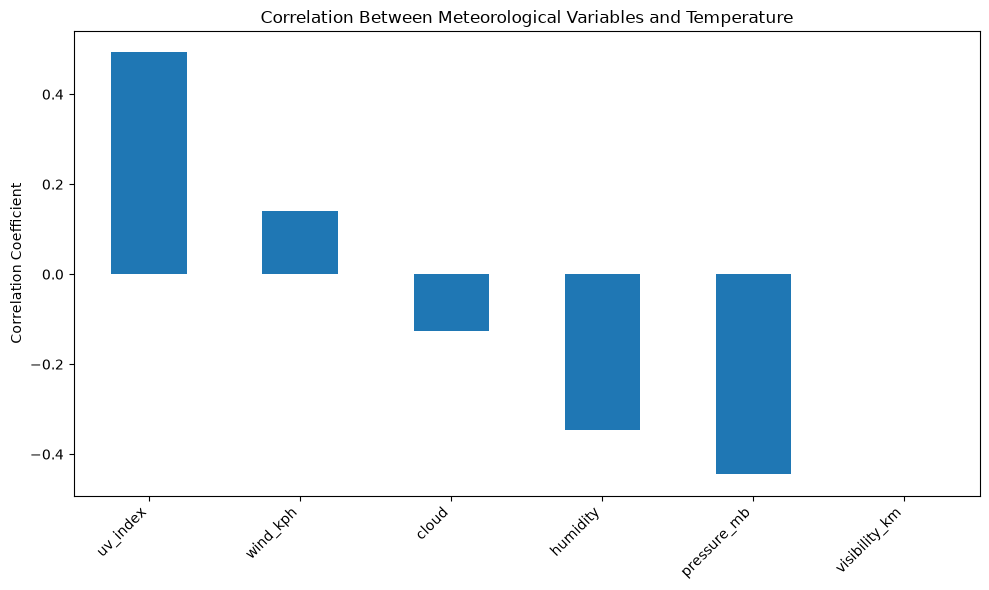

In [81]:
plt.figure(figsize=(10,6))

weather_correlations.plot(
    kind="bar",
)

plt.title(
    "Correlation Between Meteorological Variables and Temperature"
)

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()



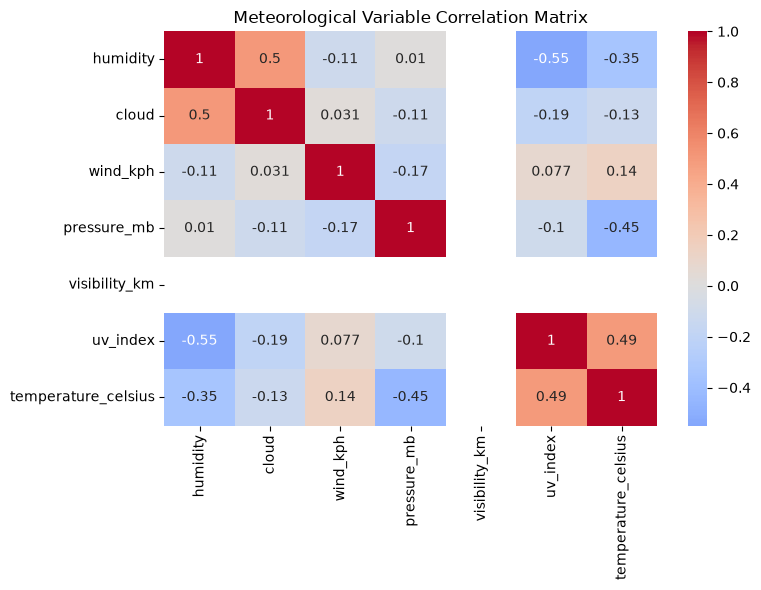

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(
    weather_df[
        weather_variables + ["temperature_celsius"]
    ].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Meteorological Variable Correlation Matrix"
)

plt.tight_layout()

plt.show()

### Discussion

The correlation analysis demonstrates that several meteorological variables exhibit meaningful relationships with observed temperature.

Among all variables evaluated, **UV Index displayed the strongest positive correlation (r = 0.493)**, indicating that warmer conditions are generally associated with higher levels of ultraviolet radiation. This relationship is expected because increased solar radiation simultaneously raises surface temperatures and UV intensity.

Atmospheric pressure exhibited a **moderate negative correlation (r = -0.445)** with temperature, suggesting that higher temperatures are generally associated with lower pressure systems. This observation is consistent with meteorological principles, where warmer air tends to rise, often resulting in reduced surface pressure.

Humidity also demonstrated a **moderate negative relationship (r = -0.346)** with temperature. While humidity and temperature frequently interact, their relationship varies depending on regional climate, precipitation, and atmospheric moisture conditions. The observed negative association suggests that warmer observations within this dataset are generally accompanied by lower relative humidity.

Cloud cover and wind speed showed relatively weak correlations with temperature, indicating that although these variables contribute to weather variability, they are less directly associated with overall temperature patterns. Visibility could not be evaluated because the dataset did not contain sufficient variation to compute a meaningful correlation coefficient.

Overall, the results indicate that ultraviolet radiation, atmospheric pressure, and humidity are the meteorological variables most strongly associated with temperature within this dataset. These findings align closely with the variables that proved important during the machine learning modeling process and further validate the predictive relationships identified throughout the forecasting pipeline.

## Summary of Variable Relationships

To summarize the exploratory analysis, the strongest geographical, environmental, and meteorological relationships with temperature are compared in a single table.

This provides an overall view of the variables most closely associated with temperature variation throughout the dataset.

In [83]:
summary_correlations = pd.Series(
    {
        "Latitude": pearson_corr,
        "Longitude": longitude_pearson,
        "UV Index": weather_correlations["uv_index"],
        "Pressure": weather_correlations["pressure_mb"],
        "Humidity": weather_correlations["humidity"],
        "Wind Speed": weather_correlations["wind_kph"],
        "Cloud Cover": weather_correlations["cloud"],
        "Ozone": air_quality_correlations["air_quality_Ozone"],
        "PM10": air_quality_correlations["air_quality_PM10"],
        "PM2.5": air_quality_correlations["air_quality_PM2.5"],
        "NO₂": air_quality_correlations["air_quality_Nitrogen_dioxide"],
        "SO₂": air_quality_correlations["air_quality_Sulphur_dioxide"],
        "CO": air_quality_correlations["air_quality_Carbon_Monoxide"],
    }
)

summary_correlations = (
    summary_correlations
    .sort_values(
        key=lambda x: abs(x),
        ascending=False,
    )
)

summary_correlations

UV Index       0.492982
Pressure      -0.445024
Latitude      -0.366183
Humidity      -0.346140
Ozone          0.256922
Longitude      0.155580
Wind Speed     0.140399
NO₂           -0.136461
Cloud Cover   -0.127283
PM10           0.115432
PM2.5          0.065535
SO₂           -0.029845
CO             0.001076
dtype: float64

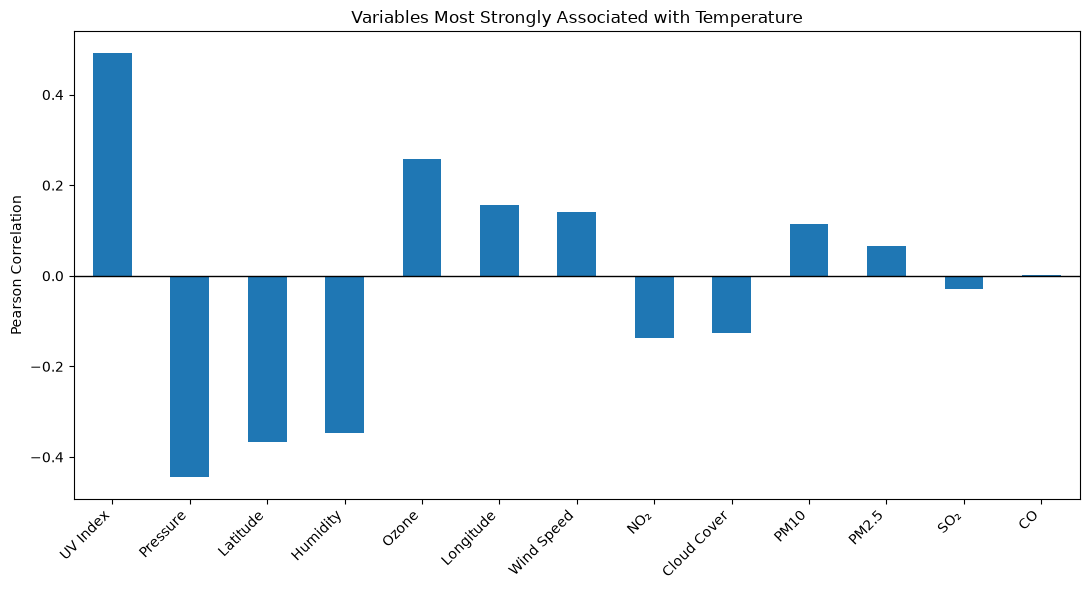

In [84]:
plt.figure(figsize=(11,6))

summary_correlations.plot(
    kind="bar",
)

plt.title(
    "Variables Most Strongly Associated with Temperature"
)

plt.ylabel("Pearson Correlation")

plt.xticks(rotation=45, ha="right")

plt.axhline(
    0,
    color="black",
    linewidth=1,
)

plt.tight_layout()

plt.show()

### Discussion

The overall correlation analysis provides a comprehensive view of the variables most strongly associated with observed temperature throughout the dataset.

Among all variables examined, **UV Index exhibited the strongest positive correlation (r = 0.493)**, indicating that higher temperatures are generally associated with increased levels of solar radiation. This finding is consistent with established atmospheric science, as greater solar exposure simultaneously increases ultraviolet intensity and surface temperature.

Atmospheric **pressure (r = -0.445)** and **latitude (r = -0.366)** displayed the strongest negative relationships with temperature. The negative association with latitude reflects the expected decrease in temperature with increasing distance from the equator, while the inverse relationship with pressure is consistent with the behavior of warm air masses and low-pressure weather systems.

Humidity also demonstrated a moderate negative correlation (r = -0.346), suggesting that warmer observations within the dataset were generally associated with lower relative humidity. Ozone showed a moderate positive relationship (r = 0.257), supporting previous findings that photochemical ozone formation is enhanced under warmer and sunnier conditions.

The remaining variables—including longitude, wind speed, cloud cover, particulate matter (PM10 and PM2.5), nitrogen dioxide, sulphur dioxide, and carbon monoxide—exhibited relatively weak correlations with temperature. While these variables contribute to overall weather conditions, they appear to have a smaller direct influence on temperature variation within this global dataset.

Overall, the exploratory analysis demonstrates that geographical position, seasonal effects, solar radiation, atmospheric pressure, and humidity are the dominant factors associated with temperature variation. These findings closely align with the variables that contributed most strongly to the predictive performance of the machine learning models developed in the previous notebooks, providing additional confidence in both the quality of the dataset and the forecasting methodology.

## Key Findings

The exploratory analysis identified several important factors influencing global temperature variation.

- Temperature decreases as latitude increases, confirming the expected global climatic pattern.
- Longitude exhibited only a weak relationship with temperature, indicating that latitude is a much stronger geographical predictor.
- Monthly and quarterly analyses revealed clear seasonal temperature cycles throughout the dataset.
- Ozone demonstrated the strongest relationship among the air quality variables, while other pollutants showed relatively weak associations with temperature.
- UV Index exhibited the strongest positive correlation with temperature, whereas atmospheric pressure and humidity displayed the strongest negative relationships.
- The variables identified through exploratory analysis closely matched those that proved valuable during the machine learning forecasting process, reinforcing the consistency between statistical exploration and predictive modeling.

## Recommendation

The exploratory analyses performed throughout this notebook provide valuable insight into the environmental and geographical factors that influence global temperature variation. The results demonstrate that latitude, seasonal variables, ultraviolet radiation, atmospheric pressure, and humidity exhibit the strongest relationships with temperature and therefore represent important predictors for forecasting models.

These findings support the feature engineering and model development decisions made throughout the previous notebooks, where temporal features, geographical information, and meteorological measurements contributed substantially to predictive performance. The consistency between exploratory analysis and machine learning results increases confidence in the robustness of the overall forecasting pipeline.

Future work could extend this analysis by incorporating additional spatial visualization techniques, regional climate clustering, lagged meteorological variables, and long-term climate trends. Combining these approaches with advanced forecasting methods such as deep learning and probabilistic prediction could further improve forecasting accuracy while providing deeper insight into global weather dynamics.

# Project Summary

This notebook concludes the exploratory and analytical portion of the weather forecasting project by summarizing the most important findings from both the statistical analyses and the machine learning experiments.

The following dashboard provides a consolidated view of the project's key outcomes, including model performance, important predictive variables, and the global distribution of weather observations.

In [104]:
summary_metrics = pd.DataFrame(
    {
        "MAE": [
            0.333420,
            0.522416,
            0.547021,
            0.345603,
            0.347151,
            0.331604,
            0.346117,
            0.168739,
        ],
        "RMSE": [
            0.426833,
            0.641529,
            0.654847,
            0.438971,
            0.438458,
            0.422005,
            0.421899,
            0.237544,
        ],
        "R2": [
            0.612629,
            0.124927,
            0.088218,
            0.590284,
            0.591242,
            0.621342,
            0.621532,
            0.942368,
        ],
    },
    index=[
        "Persistence",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "LightGBM",
        "CatBoost",
        "XGBoost",
        "Optimized Ensemble",
    ],
)

summary_metrics = summary_metrics.sort_values(
    "R2",
    ascending=False,
)

summary_metrics

,MAE,RMSE,R2
Optimized Ensemble,0.168739,0.237544,0.942368
XGBoost,0.346117,0.421899,0.621532
CatBoost,0.331604,0.422005,0.621342
Persistence,0.333420,0.426833,0.612629
LightGBM,0.347151,0.438458,0.591242
Random Forest,0.345603,0.438971,0.590284
Linear Regression,0.522416,0.641529,0.124927
Decision Tree,0.547021,0.654847,0.088218


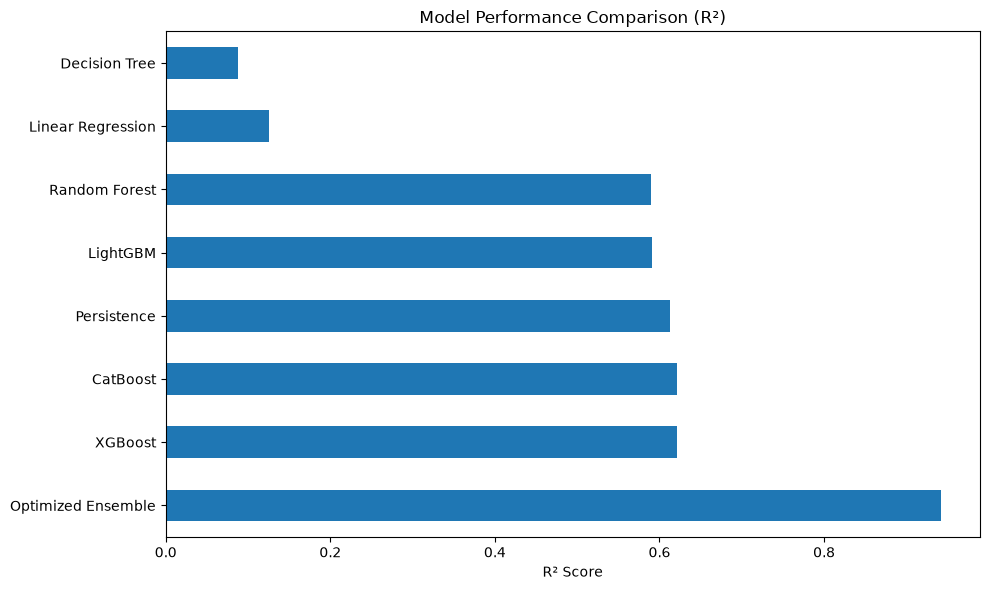

In [105]:
plt.figure(figsize=(10, 6))

summary_metrics["R2"].plot(
    kind="barh",
)

plt.title("Model Performance Comparison (R²)")
plt.xlabel("R² Score")

plt.tight_layout()

plt.show()

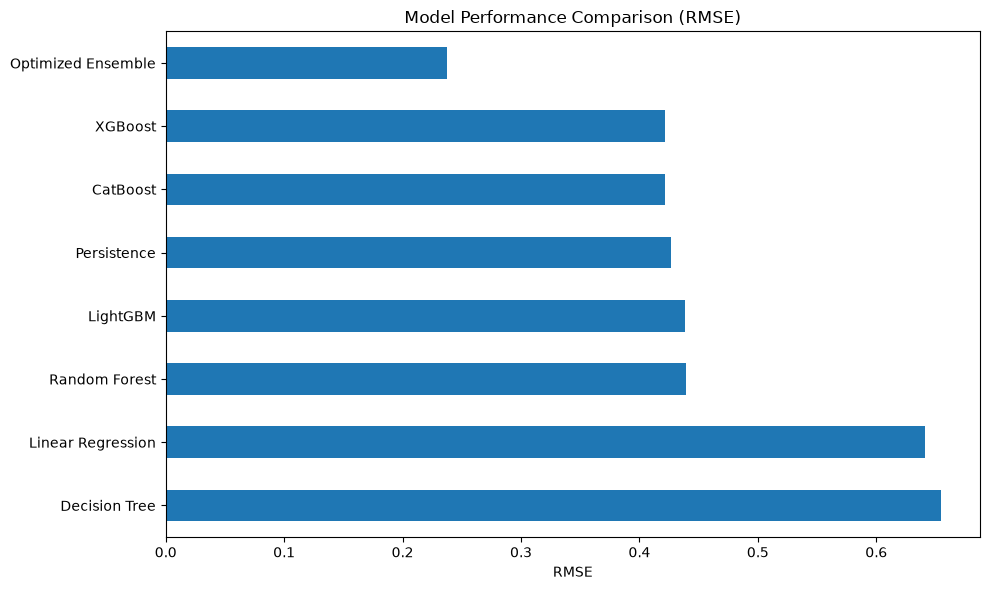

In [106]:
plt.figure(figsize=(10, 6))

summary_metrics.sort_values(
    "RMSE",
    ascending=False,
)["RMSE"].plot(
    kind="barh",
)

plt.title("Model Performance Comparison (RMSE)")
plt.xlabel("RMSE")

plt.tight_layout()

plt.show()

In [107]:
best_model = summary_metrics.iloc[0]

print("Best Model")
print("---------------------------")
print(f"Model : {summary_metrics.index[0]}")
print(f"MAE   : {best_model['MAE']:.6f}")
print(f"RMSE  : {best_model['RMSE']:.6f}")
print(f"R²    : {best_model['R2']:.6f}")

Best Model
---------------------------
Model : Optimized Ensemble
MAE   : 0.168739
RMSE  : 0.237544
R²    : 0.942368
